Fully-Connected Challenge

In this lab I will experiment with whatever fully-connected architecture/design you'd like on the dataset provided. 


 
## Lab Outline

This lab has 2 parts:

- **Part 1**: Create the network
- **Part 2**: Describe my experiments





<a id="cell2"></a>
## Part 1: Creating the network



**Goal:** A demonstrated effort to achieve as high an accuracy on this dataset as possible. 

**Data split** The data should be split into approximately 70% for training, 20% for validation, and 10% for testing. 

**Implementation** All code should be in PyTorch/python

### Some things I can try:

Things that I can experiment with:
 - number of layers
 - number of neurons per layer
 - types of activation functions
 - optimizers
 - batch sizes
 - learning rate
 - dropout layer (or not) and dropout rate
 - any other valid adjustment to the architecture as long as it remains a fully-connected network


### Tips for training
When building/tuning My model, keep in mind the following points: 

- This is experimental, so be driven by results achieved on the validation set as opposed to what I have heard/read works well or doesn't
- If the hyperparameters are working well, I should see improvement in the loss/accuracy within approximately one epoch
- For hyperparameter tuning: start by testing a large range of hyperparameters for just a few training iterations to find the combinations of parameters that are working at all
- Once I have found some sets of hyperparameters that seem to work, search more finely around these parameters. I may need to train for more epochs.
- Prefer random search to grid search for hyperparameters
- I should use the validation set for hyperparameter search and for evaluating different architectures
- The test set should only be used at the very end to evaluate my final model

### What to provide

All necessary hyperparameters should be visible either in the code or through comments. My code should include 2 plots: one for training and validation loss per epoch and one for training and validation accuracy per epoch.  

I should also evaluate and report the accuracy on the test set. The test set should be used only once. That is, after I have decided on what to include in my network and tuned any hyperparameters for my final network, I should use this final network on the test set and calculate the accuracy.  

**Please make sure that all code has been run and the output is visible in the notebook before submitting.**

## Preparing the data

Now, I need to convert the images I just uploaded into a data structure suitable for PyTorch. The goal here is to get the data into the correct shape so that I can use it with a fully connected neural network.

**I may need to reduce the resizing dimensions in order to train my models in a reasonable amount of time.**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms



transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to greyscale
    transforms.Resize((90, 90)),  # Resize to consistent dimensions
    transforms.ToTensor(),          # Convert to tensor (scales to 0-1 range)
    transforms.Lambda(lambda x: torch.flatten(x))  # Make each image a 1D tensor for input into fully-connected network
])

# Load my dataset
dataset = datasets.ImageFolder(
    root=r'Lego',
    transform=transform
)

# Check the class mapping
print("Class to index mapping:")
print(dataset.class_to_idx)

Class to index mapping:
{'brick 1x2': 0, 'brick 2x2': 1, 'brick 2x4': 2, 'plate 1x2': 3, 'plate 2x2': 4, 'plate 2x4': 5}


In [13]:
# Set device so that same code will run on CPU or GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


**Task**

Analyze the provided dataset to train and evaluate a neural network model for classification. The analysis should include data preparation, model definition, training, evaluation, visualization of results, and a summary of experiments.

**Prepare the data**

***Subtask**:
Split the dataset into training, validation, and test sets. Create DataLoader instances for each set.

In [ ]:
# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42)
)


print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Training dataset size: 3360
Validation dataset size: 960
Test dataset size: 480


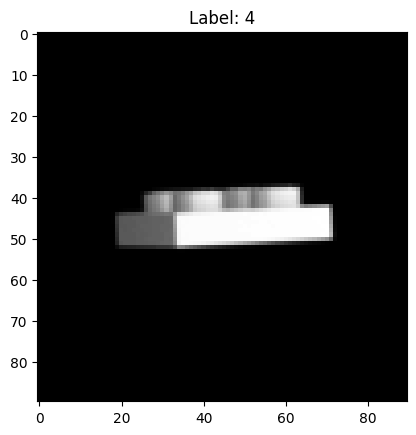

In [3]:
# viewing the image
import matplotlib.pyplot as plt
import torch

img_n = 0 # change this to view other images in the dataset
# Reshape the flattened image tensor back to its original dimensions
img_data = train_dataset[img_n][0].reshape(90,90)
plt.imshow(img_data.squeeze(), cmap='gray')
plt.title(f'Label: {train_dataset[img_n][1]}')
plt.show()

In [5]:
# Check the shape of the dataset
print("Dataset size:", len(train_dataset))
print("Shape of first image:", train_dataset[0][0].shape)

Dataset size: 3360
Shape of first image: torch.Size([8100])


In [6]:
# Print the labels of the first 10 images in the training dataset
print("Labels of the first 10 images in the training dataset:")
for i in range(10):
    print(train_dataset[i][1], end=' ') 

Labels of the first 10 images in the training dataset:
4 0 2 1 2 1 5 2 1 4 

In [7]:
#checking the shape of the test dataset
print("\nTest dataset size:", len(test_dataset))
print("Shape of first image:", test_dataset[0][0].shape)


Test dataset size: 480
Shape of first image: torch.Size([8100])


In [8]:
# Print the labels of the first 10 images in the test dataset
print("Labels of the first 10 images in the test dataset:")
for i in range(10):
    print(test_dataset[i][1], end=' ')

Labels of the first 10 images in the test dataset:
3 1 2 3 2 3 2 3 1 5 

### Build, tune, and evaluate the network

## Define the model

### Subtask:
Define a fully connected neural network model using PyTorch.

**Focus**:
Define the fully connected neural network model as instructed, including layers, activation functions, and a forward pass method.

In [ ]:
class FullyConnectedNet(nn.Module):
    def __init__(self, input_size, num_classes, hidden_layers, neurons_per_layer, dropout_rate=0.0):
        super(FullyConnectedNet, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_size, neurons_per_layer[0]))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))

        # Hidden layers
        for i in range(1, hidden_layers):
            layers.append(nn.Linear(neurons_per_layer[i-1], neurons_per_layer[i]))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

        # Output layer
        layers.append(nn.Linear(neurons_per_layer[-1], num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)



In [70]:
import torch.optim as optim

# Example usage (assuming input_size and num_classes are known)
input_size = 90 * 90  # Based on the image resizing and flattening
num_classes = len(dataset.class_to_idx) # Based on the number of unique classes in the dataset
hidden_layers = 2
neurons_per_layer = [512, 256]
dropout_rate = 0.2

# Instantiate the model and move it to the appropriate device
model = FullyConnectedNet(input_size, num_classes, hidden_layers, neurons_per_layer, dropout_rate).to(device)

# Function to count trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the model architecture and number of parameters

print("Model Architecture:")
print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")



Model Architecture:
FullyConnectedNet(
  (network): Sequential(
    (0): Linear(in_features=8100, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=6, bias=True)
  )
)

Total trainable parameters: 4,280,582


In [71]:
# Detailed breakdown of trainable parameters
for name, param in model.named_parameters():
    print(f"{name}: {param.shape} -> {param.numel()} parameters")

network.0.weight: torch.Size([512, 8100]) -> 4147200 parameters
network.0.bias: torch.Size([512]) -> 512 parameters
network.3.weight: torch.Size([256, 512]) -> 131072 parameters
network.3.bias: torch.Size([256]) -> 256 parameters
network.6.weight: torch.Size([6, 256]) -> 1536 parameters
network.6.bias: torch.Size([6]) -> 6 parameters


## Train the model

### Subtask:
Implement the training loop, including forward pass, loss calculation, backpropagation, and optimizer step. Track training and validation loss and accuracy per epoch.

**Focus:**
Implement the training loop for the specified number of epochs, including the forward and backward passes, loss calculation, and optimizer steps, and track the training and validation metrics.

In [72]:
# Choose a loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Choose an optimizer and set the learning rate
learning_rate = 0.001
optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

In [73]:
# Define batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [74]:
# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the number of training epochs
num_epochs = 20

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train

    # Validation phase
    model.eval()  # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in val_loader:
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # Calculate average validation loss and accuracy
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = 100 * correct_val / total_val

    # Print epoch results
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.2f}%, '
          f'Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_accuracy:.2f}%')

    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

print('Training complete.')

Epoch [1/20], Train Loss: 1.6860, Train Accuracy: 57.26%, Validation Loss: 0.7950, Validation Accuracy: 69.38%
Epoch [2/20], Train Loss: 0.6993, Train Accuracy: 74.17%, Validation Loss: 0.6593, Validation Accuracy: 77.71%
Epoch [3/20], Train Loss: 0.6343, Train Accuracy: 76.22%, Validation Loss: 0.5498, Validation Accuracy: 82.81%
Epoch [4/20], Train Loss: 0.5726, Train Accuracy: 78.93%, Validation Loss: 0.5526, Validation Accuracy: 82.71%
Epoch [5/20], Train Loss: 0.5048, Train Accuracy: 81.90%, Validation Loss: 0.6899, Validation Accuracy: 75.83%
Epoch [6/20], Train Loss: 0.4706, Train Accuracy: 83.72%, Validation Loss: 0.7959, Validation Accuracy: 68.44%
Epoch [7/20], Train Loss: 0.4274, Train Accuracy: 85.48%, Validation Loss: 0.5160, Validation Accuracy: 83.65%
Epoch [8/20], Train Loss: 0.3806, Train Accuracy: 86.61%, Validation Loss: 0.5443, Validation Accuracy: 79.90%
Epoch [9/20], Train Loss: 0.3608, Train Accuracy: 87.74%, Validation Loss: 0.4668, Validation Accuracy: 84.27%
E

## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and report the accuracy.

**Focus**:
Evaluate the trained model on the test set and report the accuracy based on the provided instructions.

In [75]:
# Evaluate the model on the test set
model.eval()  # Set model to evaluation mode
correct_test = 0
total_test = 0

with torch.no_grad():  # Disable gradient calculation
    for inputs, labels in test_loader:
        # Forward pass
        outputs = model(inputs)

        # Get predicted class labels
        _, predicted = torch.max(outputs.data, 1)

        # Update counts
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

# Calculate test accuracy
test_accuracy = 100 * correct_test / total_test

# Print test accuracy
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 88.33%


## Visualize results

### Subtask:
Plot the training and validation loss and accuracy curves.

**Focus**:
Plot the training and validation loss and accuracy curves using matplotlib.

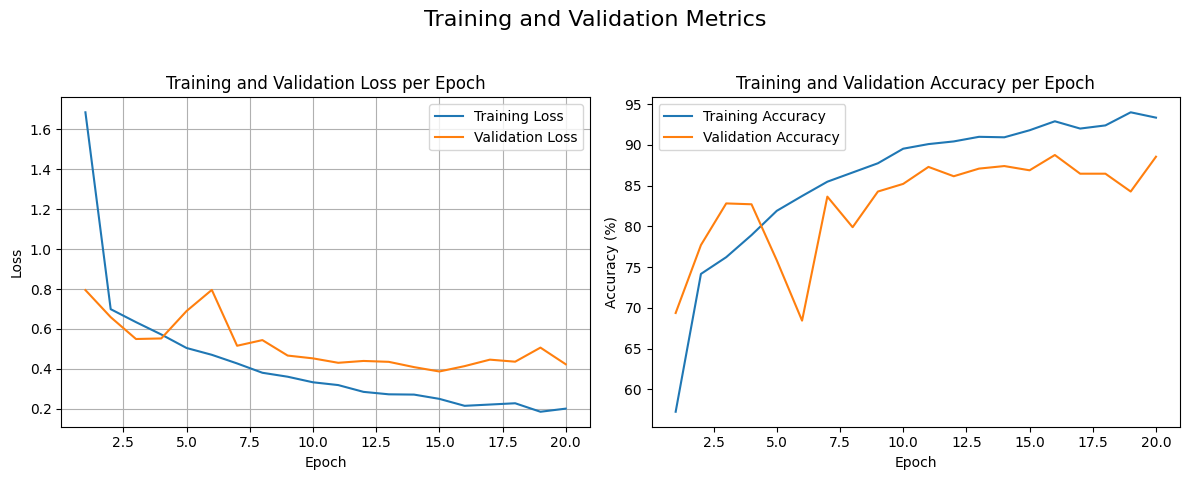

In [78]:
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.title('Training and Validation Loss per Epoch')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy per Epoch')
plt.legend()

# Add a title to the entire figure
plt.suptitle('Training and Validation Metrics', fontsize=16)

# Display the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Part 2: Describe what I did (50% of grade)

All the work I did leading up to my final model should be summarized in this section. This should be a logical and well-organized summary of the various experiments that were tried in [Part 1](#cell2), and should be captured in **table format** . Upon reading this section I should understand what I tried, the reasoning behind trying it, any quantitative values that correspond to what I tried, and the results. 

**myexperiments should try out different aspects of the network architecture. For example, trying a hidden layer with 256 neurons, then 512, then 1024, then 2048 would be considered ONE experiment NOT four.**

See [this guide](https://www.datacamp.com/community/tutorials/markdown-in-jupyter-notebook) for how to format markdown cells in Jupyter notebooks. 

**The table below is just an example; it should be modified to fit the experiments I did.**


|Experiment | Learning Rate | Optimizer | Activation Function | No. Layers (excl. input) | No. Neurons/Layer | Batch Size | No. Epochs | Dropout (Y/N) | No. Parameters | Training Accuracy | Validation Accuracy |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| 1 | 0.001 | RMSprop | ReLU | 3 | [512, 256,6] | 32 | 4 | Yes-0.2 | 4,280,582 | 95.36% | 86.67% |
| 2 | 0.01 | Adam | ReLU | 3 | [1024, 512, 6] | 64 | 5 | Yes-0.3 | 8,823,302 | 71.73% | 77.71% |
| 3 | 0.01 | Adam | Sigmoid | 4 | [1024, 512, 256, 6] | 128 | 5 | Yes-0.3 | 8,953,094 | 66.85% | 77.08% |
| 4 | 0.001 | RMSprop | ReLU | 4 | [1024, 512, 256, 6] | 256 | 5 | Yes-0.2 | 8,953,094 | 75.06% | 75.00% |
| 5 | 0.01 | RMSprop | Sigmoid | 4 | [1024, 512, 256, 6] | 64 | 5 | Yes-0.2 | 8,953,094 | 16.13% | 17.29% |
| 6 | 0.001 | Adam | ReLU | 3 | [256, 128, 6] | 64 | 15 | Yes-0.3 | 2,107,526 | 89.97% | 87.08% |
| 7 | 0.001 | Adam | ReLU | 4 | [256, 128, 64, 6] | 32 | 15 | Yes-0.2 | 2,115,398 | 90.68% | 84.48% |
| 8 | 0.0005 | Adam | ReLU | 3 | [512, 256, 6] | 128 | 20 | Yes-0.3 | 4,280,582 | 91.90% | 87.29% |
| 9 | 0.001 | Adam | Sigmoid | 3 | [256, 128, 6] | 64 | 15 | Yes-0.5 | 2,107,526 | 84.52% | 85.94% | 
| 10 | 0.001 | Adam | ReLU | 3 | [256, 128, 6] | 64 | 15 | Yes-0.3 | 2,107,526 | 89.91% | 86.04% |
| 11 | 0.001 | RMSprop | ReLU | 4 | [512, 256, 128, 6] | 64 | 15 | Yes-0.5 | 4,312,710 | 52.02% | 56.88% |
| 12 | 0.001 | SGD | ReLU | 3 | [256, 128, 6] | 64 | 25 | Yes-0.3 | 2,107,526 | 39.35% | 37.29% |
| 13 | 0.001 | Adam | ReLU | 3 | [512, 256, 6] | 64 | 15 | Yes-0.3 | 4,280,582 |91.34% | 87.08% |
| 14 | 0.001 | RMSprop | ReLU | 3 | [512, 256, 6] | 64 | 20 | Yes-0.2 | 4,280,582 | 93.33% | 88.54% |

## Summary:

### Data Analysis Key Findings

Based on the experiments conducted and summarized in the table above, analyzing primarily training and validation performance:

* **Experiment 1** achieved the highest training accuracy (**95.36%**) and a strong validation accuracy (**86.67%**) using a learning rate of 0.001, RMSprop optimizer, ReLU activation, 3 layers with [512, 256, 6] neurons, batch size 32, 4 epochs, and dropout of 0.2. But the validation  accuracy is lower than experiment 14, indicating potential overfitting.
* **Experiment 14** also performed well, with a training accuracy of **93.33%** and validation accuracy of **88.54%**, using a similar architecture but with 20 epochs and batch size 64. this seems like the best performed in all the experimented model so we used it to evaluate our testdataset and got an accuracy of **88.33%**.
although from the plot the lowest validation loss in this model  was achieved at 15 epochs .
* **Experiment 8** (Adam optimizer, learning rate 0.0005, batch size 128, 20 epochs, dropout 0.3) achieved high training (**91.90%**) and validation (**87.29%**) accuracies, showing that Adam can also be effective with appropriate hyperparameters.
* Using the Adam optimizer with a lower learning rate and more epochs (Experiments 6, 7, 8, 9, 10, 13) generally resulted in high training and validation accuracies, especially with ReLU activation and moderate dropout.
* **Experiment 12** (SGD optimizer) resulted in significantly lower training (**39.35%**) and validation (**37.29%**) accuracies, highlighting the importance of optimizer choice.
* Increasing the number of layers or neurons (Experiments 2, 3, 4, 11) did not always improve validation accuracy and sometimes led to overfitting or diminishing returns.
* Dropout rates above 0.3 (Experiments 4, 9, 11) tended to reduce training accuracy, but sometimes helped with generalization, as seen in validation accuracy.
* ReLU activation consistently outperformed Sigmoid in this dataset, as shown by higher accuracies in most experiments using ReLU.

In summary, the best results were achieved with RMSprop or Adam optimizers, ReLU activation, 2-3 hidden layers, moderate dropout (0.2-0.3), and careful tuning of learning rate and batch size.

### References

**This includes acknowledging the use of any AI service like ChatGPT and how I used it.**

Please include all references used in completing this lab: books, tutorials, blogs, github, etc.

<ol>
<li>Reference details: PyTorch Documentation and link : https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.random_split . 
used verify the library to import and the libraries works</li>
<li>Reference details: Open AI (ChatGPT, Gemini and Copilot) used it for code verification and code explanation. VSCode Copilot helped in the finishing up some the code which we verified and understood before running</li>
<li>Reference details: Class note and pyton files. Use it for reference to know and understand what the lab required from us to do </li>
<li>etc.</li>
</ol>